In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import classification_report, roc_auc_score, f1_score, recall_score, precision_score, precision_recall_curve, confusion_matrix, ConfusionMatrixDisplay
from imblearn.pipeline import Pipeline 
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split, StratifiedKFold
import torch
import torch.nn as nn


In [4]:
df = pd.read_csv("data/train-cat-encoded.csv")
print("Training set size: ", df.shape)


Training set size:  (668665, 22)


In [5]:
y = df['Will_Buy_EV']
x = df.drop(columns=['Will_Buy_EV'])


## Build Baseline model

In [ ]:
n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
subsetNum = 50000
subset_x = x.iloc[:subsetNum]
subset_y = y.iloc[:subsetNum]


### Dummy Classifier

==========Dummy Classifier Cross Validation Training Loop==========

========== FOLD 1 ==========
Fold 1 | AUC: 0.4882
F1: 0.2453 | Recall: 0.4725 | Precision: 0.1657


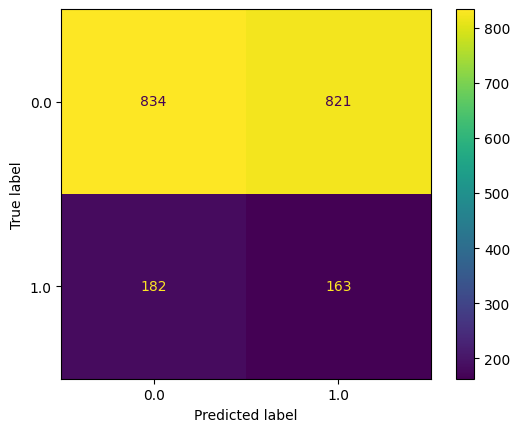

Finished Fold 1

========== FOLD 2 ==========
Fold 2 | AUC: 0.5162
F1: 0.2694 | Recall: 0.5188 | Precision: 0.1819


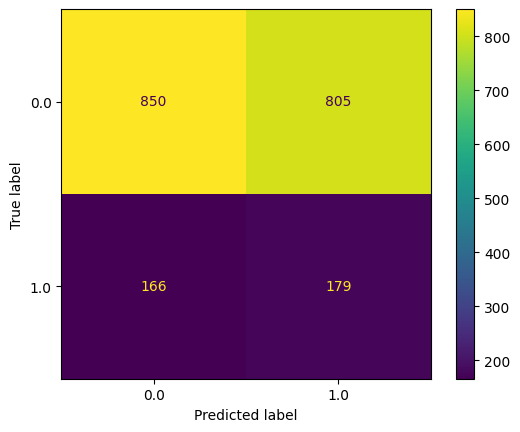

Finished Fold 2

========== FOLD 3 ==========
Fold 3 | AUC: 0.5188
F1: 0.2722 | Recall: 0.5231 | Precision: 0.1839


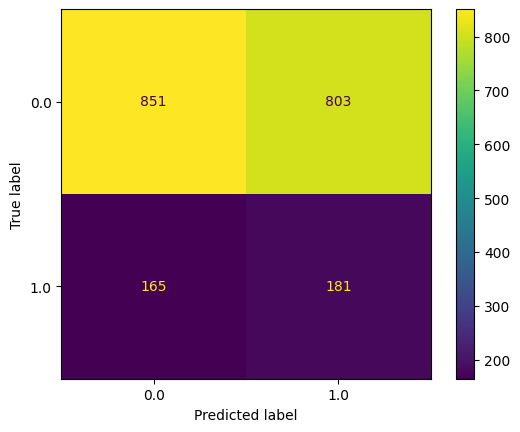

Finished Fold 3

========== FOLD 4 ==========
Fold 4 | AUC: 0.5066
F1: 0.2617 | Recall: 0.5029 | Precision: 0.1768


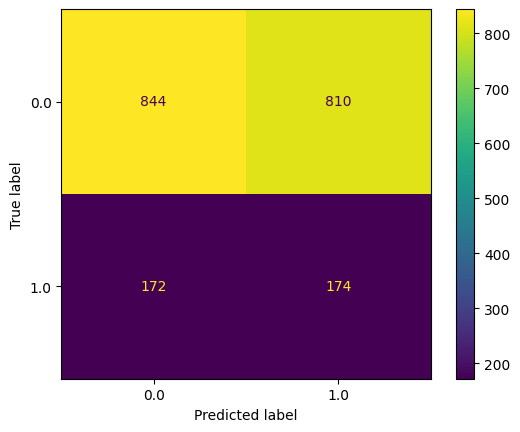

Finished Fold 4

========== FOLD 5 ==========
Fold 5 | AUC: 0.5223
F1: 0.2752 | Recall: 0.5289 | Precision: 0.1860


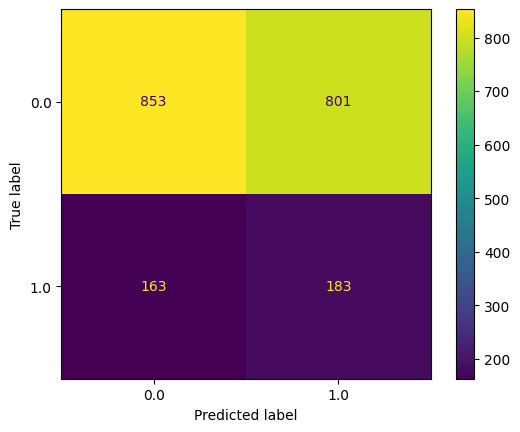

Finished Fold 5
Avg AUC: 0.5104
Std AUC: 0.012281107591446435


In [7]:
dummyAucList = []
dummyF1List = []
dummyRecallList = []
dummyPrecisionList = []

print("==========Dummy Classifier Cross Validation Training Loop==========")
for fold, (train_idx, val_idx) in enumerate(skf.split(subset_x, subset_y)):
    print(f"\n========== FOLD {fold + 1} ==========")
    
    # 1. Split data (using .iloc if X/y are pandas DataFrames)
    X_train, X_val = subset_x.iloc[train_idx], subset_x.iloc[val_idx]
    y_train, y_val = subset_y.iloc[train_idx], subset_y.iloc[val_idx]
    
    model = DummyClassifier(random_state=42, strategy='uniform')
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    auc = roc_auc_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)
    recall = recall_score(y_val, y_pred)
    precision = precision_score(y_val, y_pred)

    print(f"Fold {fold + 1} | AUC: {auc:.4f}")
    print(f"F1: {f1:.4f} | Recall: {recall:.4f} | Precision: {precision:.4f}")
    ConfusionMatrixDisplay.from_predictions(y_val, y_pred)
    plt.show()
    dummyAucList.append(auc)
    dummyF1List.append(f1)
    dummyRecallList.append(recall)
    dummyPrecisionList.append(precision)
              
    print(f"Finished Fold {fold + 1}")

print(f"Avg AUC: {(sum(dummyAucList) / n_splits):.4f}")
print(f"Std AUC: {np.std(dummyAucList)}")


### RandomForest Classifier

==========Random Forest Classifier Cross Validation Training Loop==========

========== FOLD 1 ==========


Fold 1 | AUC: 0.7830
F1: 0.6742 | Recall: 0.6058 | Precision: 0.7600


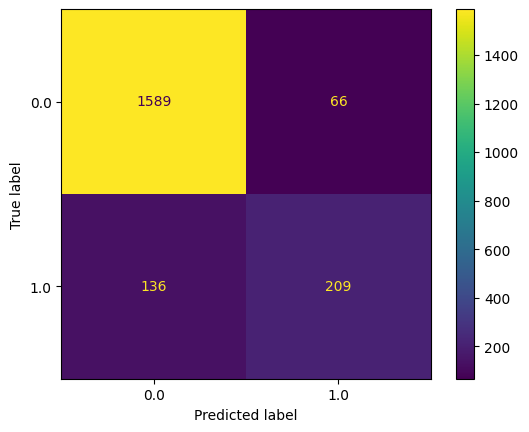

Finished Fold 1

========== FOLD 2 ==========
Fold 2 | AUC: 0.7613
F1: 0.6334 | Recall: 0.5710 | Precision: 0.7112


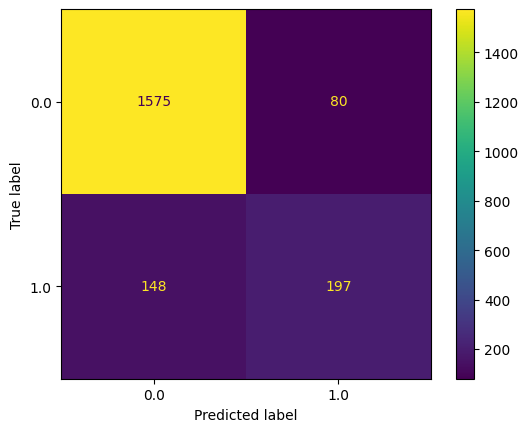

Finished Fold 2

========== FOLD 3 ==========
Fold 3 | AUC: 0.7756
F1: 0.6592 | Recall: 0.5954 | Precision: 0.7384


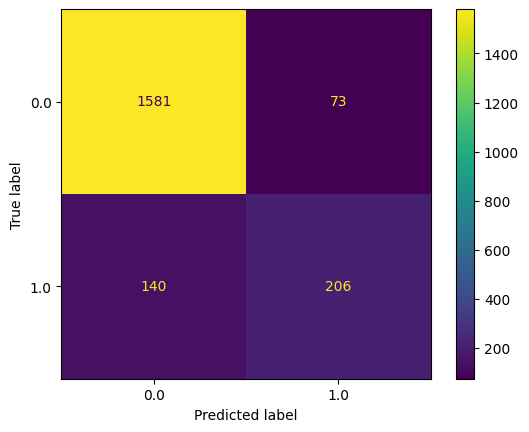

Finished Fold 3

========== FOLD 4 ==========
Fold 4 | AUC: 0.7584
F1: 0.6389 | Recall: 0.5549 | Precision: 0.7529


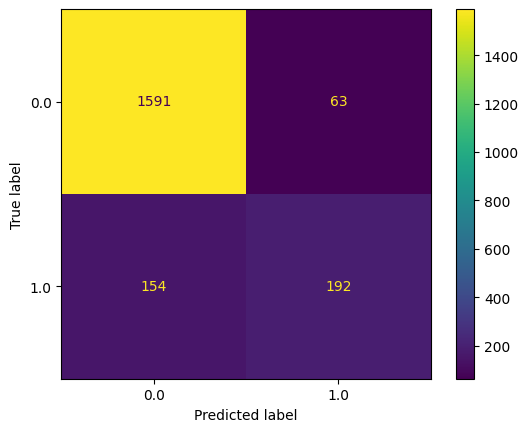

Finished Fold 4

========== FOLD 5 ==========
Fold 5 | AUC: 0.7574
F1: 0.6299 | Recall: 0.5607 | Precision: 0.7185


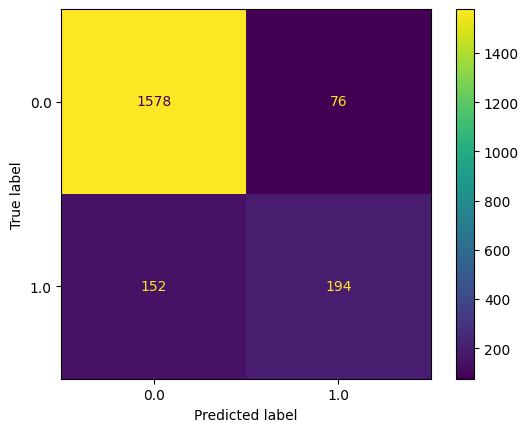

Finished Fold 5
Avg AUC: 0.7671
Std AUC: 0.010270389933355032


In [8]:
rForestAucList = []
rForestF1List = []
rForestRecallList = []
rForestPrecisionList = []

print("==========Random Forest Classifier Cross Validation Training Loop==========")
for fold, (train_idx, val_idx) in enumerate(skf.split(subset_x, subset_y)):
    print(f"\n========== FOLD {fold + 1} ==========")
    
    # 1. Split data (using .iloc if X/y are pandas DataFrames)
    X_train, X_val = subset_x.iloc[train_idx], subset_x.iloc[val_idx]
    y_train, y_val = subset_y.iloc[train_idx], subset_y.iloc[val_idx]
    
    model = RandomForestClassifier(random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    auc = roc_auc_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)
    recall = recall_score(y_val, y_pred)
    precision = precision_score(y_val, y_pred)

    print(f"Fold {fold + 1} | AUC: {auc:.4f}")
    print(f"F1: {f1:.4f} | Recall: {recall:.4f} | Precision: {precision:.4f}")
    ConfusionMatrixDisplay.from_predictions(y_val, y_pred)
    plt.show()
    rForestAucList.append(auc)
    rForestF1List.append(f1)
    rForestRecallList.append(recall)
    rForestPrecisionList.append(precision)
              
    print(f"Finished Fold {fold + 1}")

print(f"Avg AUC: {(sum(rForestAucList) / n_splits):.4f}")
print(f"Std AUC: {np.std(rForestAucList)}")


### Logistic Regression Classifier

==========Logistic Classifier Cross Validation Training Loop==========

========== FOLD 1 ==========
Fold 1 | AUC: 0.7739
F1: 0.6570 | Recall: 0.5913 | Precision: 0.7391


c:\Users\wenyu\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


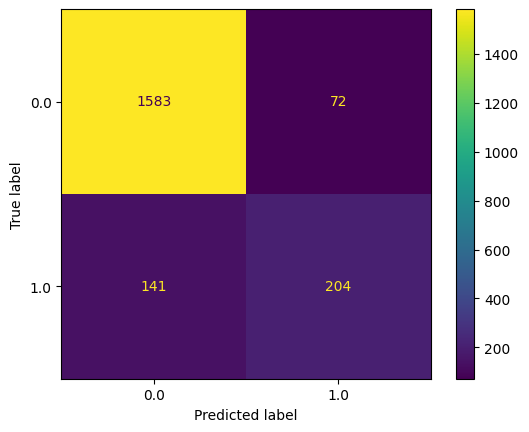

Finished Fold 1

========== FOLD 2 ==========
Fold 2 | AUC: 0.7939
F1: 0.6707 | Recall: 0.6464 | Precision: 0.6969


c:\Users\wenyu\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


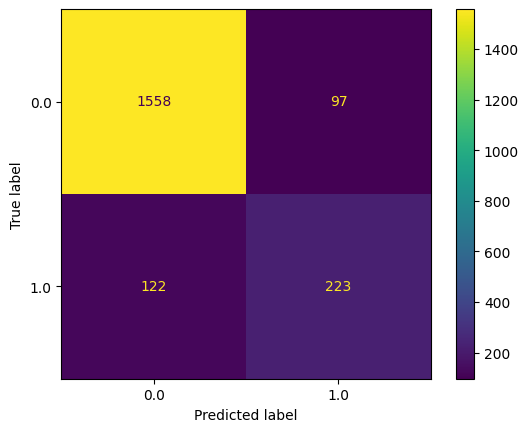

Finished Fold 2

========== FOLD 3 ==========
Fold 3 | AUC: 0.7266
F1: 0.5757 | Recall: 0.5058 | Precision: 0.6679


c:\Users\wenyu\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


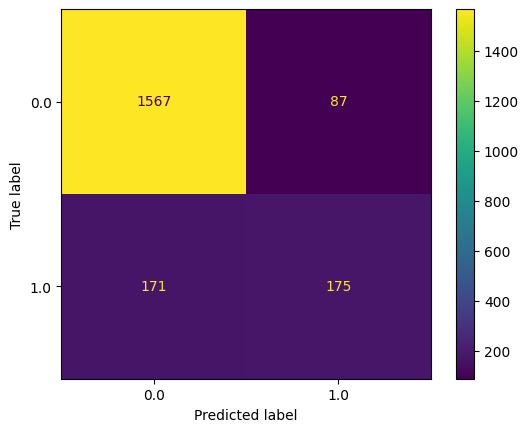

Finished Fold 3

========== FOLD 4 ==========
Fold 4 | AUC: 0.7497
F1: 0.6028 | Recall: 0.5636 | Precision: 0.6478


c:\Users\wenyu\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


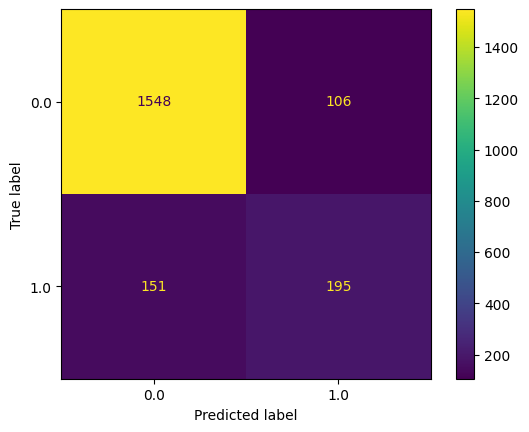

Finished Fold 4

========== FOLD 5 ==========
Fold 5 | AUC: 0.7635
F1: 0.6293 | Recall: 0.5838 | Precision: 0.6824


c:\Users\wenyu\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


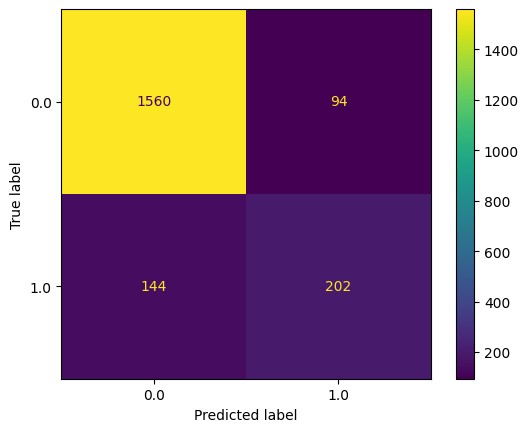

Finished Fold 5
Avg AUC: 0.7615
Std AUC: 0.022641491992209207


In [9]:
logAucList = []
logF1List = []
logRecallList = []
logPrecisionList = []

print("==========Logistic Classifier Cross Validation Training Loop==========")
for fold, (train_idx, val_idx) in enumerate(skf.split(subset_x, subset_y)):
    print(f"\n========== FOLD {fold + 1} ==========")
    
    # 1. Split data (using .iloc if X/y are pandas DataFrames)
    X_train, X_val = subset_x.iloc[train_idx], subset_x.iloc[val_idx]
    y_train, y_val = subset_y.iloc[train_idx], subset_y.iloc[val_idx]
    
    model = LogisticRegression(random_state=42, max_iter=1000)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    auc = roc_auc_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)
    recall = recall_score(y_val, y_pred)
    precision = precision_score(y_val, y_pred)

    print(f"Fold {fold + 1} | AUC: {auc:.4f}")
    print(f"F1: {f1:.4f} | Recall: {recall:.4f} | Precision: {precision:.4f}")
    ConfusionMatrixDisplay.from_predictions(y_val, y_pred)
    plt.show()
    logAucList.append(auc)
    logF1List.append(f1)
    logRecallList.append(recall)
    logPrecisionList.append(precision)
              
    print(f"Finished Fold {fold + 1}")

print(f"Avg AUC: {(sum(logAucList) / n_splits):.4f}")
print(f"Std AUC: {np.std(logAucList)}")


==========SVM Classifier Cross Validation Training Loop==========

========== FOLD 1 ==========
Fold 1 | AUC: 0.6270
F1: 0.3815 | Recall: 0.3942 | Precision: 0.3696


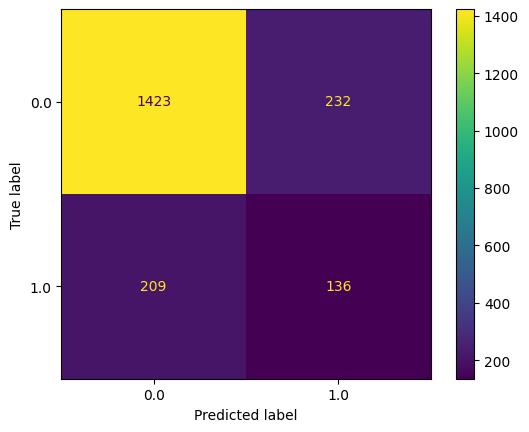

Finished Fold 1

========== FOLD 2 ==========
Fold 2 | AUC: 0.5755
F1: 0.2960 | Recall: 0.2870 | Precision: 0.3056


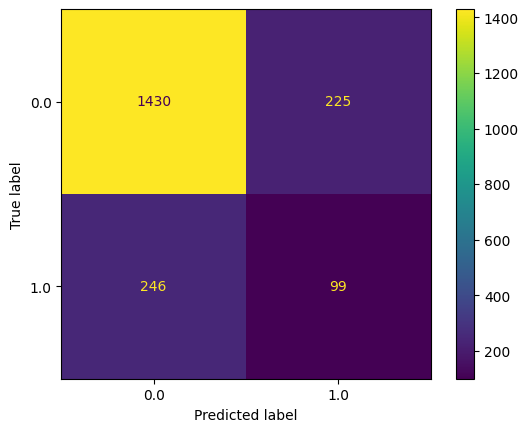

Finished Fold 2

========== FOLD 3 ==========
Fold 3 | AUC: 0.5897
F1: 0.3213 | Recall: 0.3208 | Precision: 0.3217


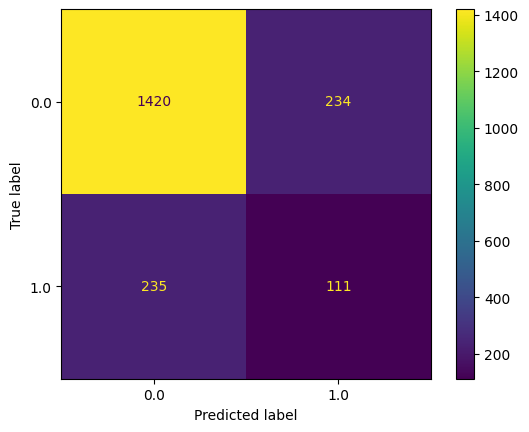

Finished Fold 3

========== FOLD 4 ==========
Fold 4 | AUC: 0.5705
F1: 0.2891 | Recall: 0.2861 | Precision: 0.2920


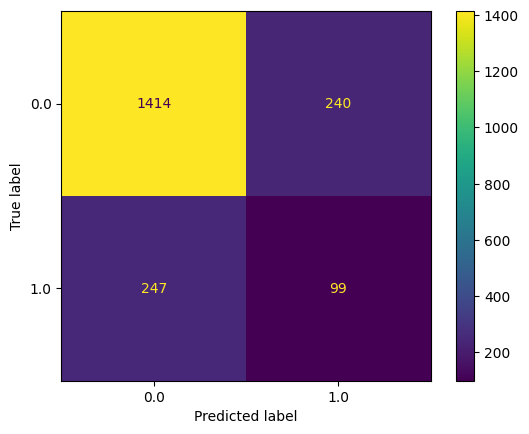

Finished Fold 4

========== FOLD 5 ==========
Fold 5 | AUC: 0.5725
F1: 0.2928 | Recall: 0.2919 | Precision: 0.2936


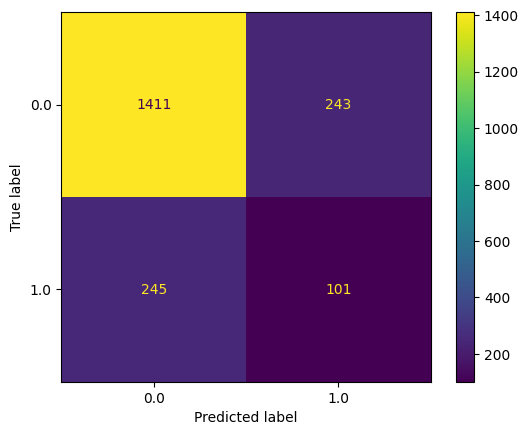

Finished Fold 5
Avg AUC: 0.5870
Std AUC: 0.021082667669645814


In [10]:
svmAucList = []
svmF1List = []
svmRecallList = []
svmPrecisionList = []

print("==========SVM Classifier Cross Validation Training Loop==========")
for fold, (train_idx, val_idx) in enumerate(skf.split(subset_x, subset_y)):
    print(f"\n========== FOLD {fold + 1} ==========")
    
    # 1. Split data (using .iloc if X/y are pandas DataFrames)
    X_train, X_val = subset_x.iloc[train_idx], subset_x.iloc[val_idx]
    y_train, y_val = subset_y.iloc[train_idx], subset_y.iloc[val_idx]
    
    model = SVC(random_state=42, kernel='sigmoid')
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    auc = roc_auc_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)
    recall = recall_score(y_val, y_pred)
    precision = precision_score(y_val, y_pred)

    print(f"Fold {fold + 1} | AUC: {auc:.4f}")
    print(f"F1: {f1:.4f} | Recall: {recall:.4f} | Precision: {precision:.4f}")
    ConfusionMatrixDisplay.from_predictions(y_val, y_pred)
    plt.show()
    svmAucList.append(auc)
    svmF1List.append(f1)
    svmRecallList.append(recall)
    svmPrecisionList.append(precision)
              
    print(f"Finished Fold {fold + 1}")

print(f"Avg AUC: {(sum(svmAucList) / n_splits):.4f}")
print(f"Std AUC: {np.std(svmAucList)}")


In [34]:
results = {
    "Dummy":               (dummyF1List,   dummyAucList,   dummyPrecisionList,   dummyRecallList),
    "Random Forest":       (rForestF1List, rForestAucList, rForestPrecisionList, rForestRecallList),
    "Logistic Regression": (logF1List,     logAucList,     logPrecisionList,     logRecallList),
    "SVM":                 (svmF1List,     svmAucList,     svmPrecisionList,     svmRecallList),
}

def stat(values):
    if not values:
        return "not run"
    return f"{np.mean(values):.4f} ± {np.std(values):.4f}"

header = f"{'Model':<22} | {'F1 (Avg ± Std)':<17} | {'AUC (Avg ± Std)':<17} | {'Precision (Avg ± Std)':<23} | {'Recall (Avg ± Std)':<17}"
print(header)
print("-" * len(header))

for name, (f1s, aucs, precs, recs) in results.items():
    print(
        f"{name:<22} | {stat(f1s):<17} | {stat(aucs):<17} | {stat(precs):<23} | {stat(recs):<17}"
    )


Model                  | F1 (Avg ± Std)    | AUC (Avg ± Std)   | Precision (Avg ± Std)   | Recall (Avg ± Std)
-------------------------------------------------------------------------------------------------------------
Dummy                  | 0.2647 ± 0.0107   | 0.5104 ± 0.0123   | 0.1789 ± 0.0073         | 0.5092 ± 0.0203  
Random Forest          | 0.6471 ± 0.0169   | 0.7671 ± 0.0103   | 0.7362 ± 0.0189         | 0.5776 ± 0.0198  
Logistic Regression    | 0.6271 ± 0.0347   | 0.7615 ± 0.0226   | 0.6868 ± 0.0308         | 0.5782 ± 0.0454  
SVM                    | 0.3161 ± 0.0346   | 0.5870 ± 0.0211   | 0.3165 ± 0.0286         | 0.3160 ± 0.0411  


In [11]:

class BaseLineNN(nn.Module):
    def __init__(self, input_size, l1, output_size):
        super(BaseLineNN, self).__init__()
        self.layer1 = nn.Linear(input_size, l1, bias=False)
        self.layer2 = nn.Linear(l1, output_size, bias=False)

    def forward(self, x):
        y = self.layer1(x)
        y_hat = torch.relu(y)
        scores = self.layer2(y_hat)
        # prob = torch.softmax(scores)
        return scores


In [ ]:
feature_tensor = torch.tensor(subset_x.values, dtype=torch.float32)
label_tensor = torch.tensor(subset_y.values, dtype=torch.float32)
print(feature_tensor.shape)
print(label_tensor.shape)


torch.Size([10000, 21])
torch.Size([10000])


In [16]:
net = BaseLineNN(feature_tensor.size(1), 10, 2)

criterion = nn.CrossEntropyLoss()
optimizer=torch.optim.SGD( net.parameters() , lr=0.01 )
bs = 20


In [ ]:
# for epoch in range(40):
    
#     running_loss=0
#     running_error=0
#     num_batches=0
    
#     shuffled_indices=torch.randperm(50000)
 
#     for count in range(0,50000,bs):
    
#         # Set the gradients to zeros
#         optimizer.zero_grad()
        
#         # create a minibatch       
#         indices=shuffled_indices[count:count+bs]
#         minibatch_data =  train_data[indices]
#         minibatch_label= train_label[indices]

#         # reshape the minibatch
#         inputs = minibatch_data.view(bs,21)

#         # tell Pytorch to start tracking all operations that will be done on "inputs"
#         inputs.requires_grad_()

#         # forward the minibatch through the net 
#         scores=net( inputs ) 

#         # Compute the average of the losses of the data points in the minibatch
#         loss =  criterion( scores , minibatch_label) 
        
#         # backward pass to compute dL/dU, dL/dV and dL/dW   
#         loss.backward()

#         # do one step of stochastic gradient descent: U=U-lr(dL/dU), V=V-lr(dL/dU), ...
#         optimizer.step()
        
#         # START COMPUTING STATS
        
#         # add the loss of this batch to the running loss
#         running_loss += loss.detach().item()
        
#         # compute the error made on this batch and add it to the running error       
#         # error = utils.get_error( scores.detach() , minibatch_label)
#         # running_error += error.item()
        
#         num_batches+=1
    
    
#     # compute stats for the full training set
#     total_loss = running_loss/num_batches
#     # total_error = running_error/num_batches
    
#     print('epoch=',epoch, '\t loss=', total_loss)
